In [2]:
pip install odfpy

     ---------------------------------------- 0.0/717.0 kB ? eta -:--:--
     -------------------------------------- 717.0/717.0 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=137565 sha256=110d8d66c29dcb327f57f12156b607ec5162cefb0980465618c3373ef5af7b93
  Stored in directory: c:\users\syedm\appdata\local\pip\cache\wheels\8e\cd\9f\979443982946991080916064e4c049b91941be1800825ff74b
Successfully built odfpy

   ---------------------------------------- 0/2 [defusedxml]
   -------------------- ------------------- 1/2 [odfpy]
   -------------------- ------------------- 1/2 [odfpy]
   -------------------- ------------------- 1/2 [odfpy]
   -------------------- ------------------- 1/2 [odfpy]
   -------------------- ------------------- 1/2 [odfpy]
   -------------------- ------------------- 1/2 [odfpy]
   -------------------------------------

  DEPRECATION: Building 'odfpy' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'odfpy'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Reading file: C:\Users\syedm\Code\K223 Pseudo Data.ods
Sheets found: ['Prompt Curve', 'Spectrum', 'Angular Correlation', 'Threshold Scan']

Prompt Curve Fit (manual Eq. 4 style)
------------------------------------------------------------------------
           A =      998.208 ± 11.6
          t0 =      46.0796 ± 0.112
           w =      31.8393 ± 0.247
       sigma =      5.15831 ± 0.225
          A0 =      100.153 ± 2.96
     meaning = w is plateau width / resolving-time proxy
               sigma is slope width
        chi2 = 25.8656
         ndf = 27
    chi2/ndf = 0.957984



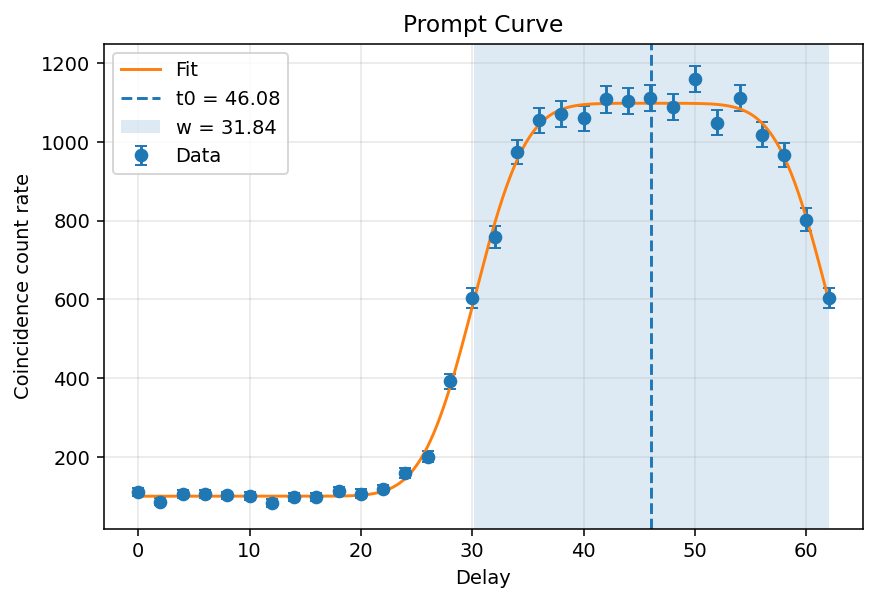

Spectrum Fit (practical helper fit: 2 Gaussians + constant background)
------------------------------------------------------------------------
        amp1 =       1131.1 ± 39.5
         mu1 =       90.532 ± 0.349
      sigma1 =      9.41645 ± 0.429
        amp2 =      2964.86 ± 75.9
         mu2 =      128.105 ± 0.0891
      sigma2 =      4.42883 ± 0.115
          bg =      3604.56 ± 24.2
        chi2 = 2149.44
         ndf = 19
    chi2/ndf = 113.128



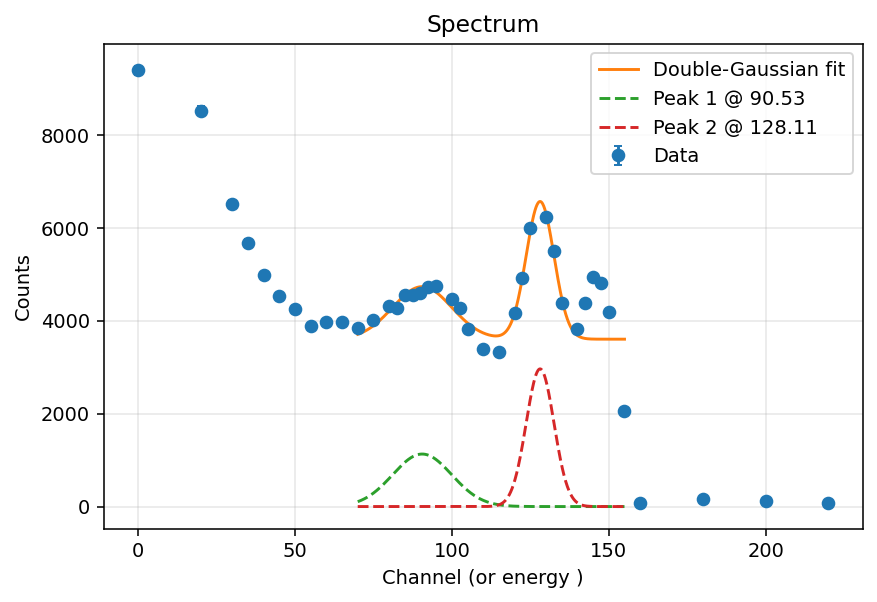

Angular Correlation Fit
------------------------------------------------------------------------
           A =      10003.6 ± 46.9
           B =    0.0927159 ± 0.0267
           C =    0.0790807 ± 0.0262
       alpha =     0.171797 ± 0.0374
        beta =    0.0136351 ± 0.0374
     meaning = alpha = B + C, beta = B - C
        chi2 = 18.3204
         ndf = 16
    chi2/ndf = 1.14503



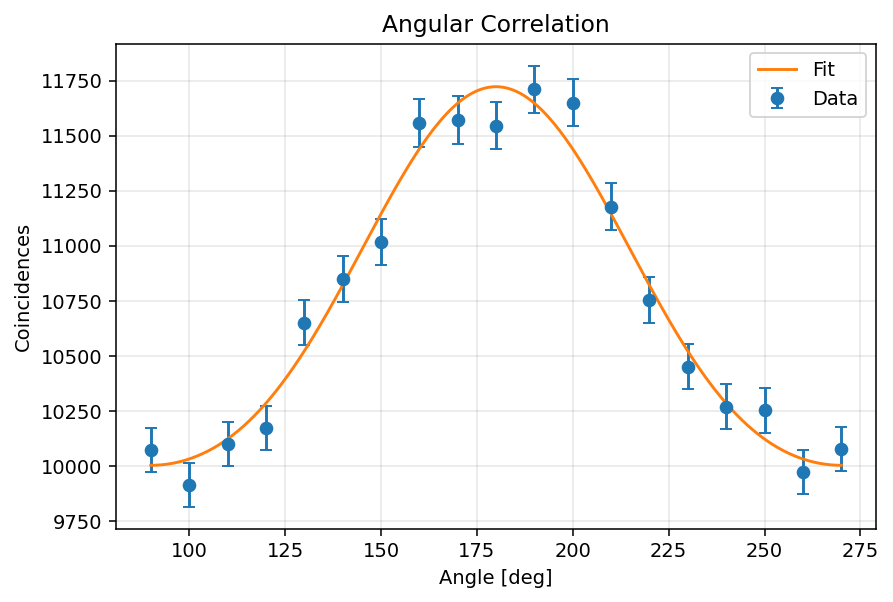

Threshold Scan Fit — Source Installed (helper fit)
------------------------------------------------------------------------
        high =      98603.2 ± 75
          x0 =      331.083 ± 0.0341
           k =      3.80198 ± 0.0117
         low =  2.58997e-34 ± 0.568
     meaning = x0 is the approximate threshold turnoff point
        chi2 = 1.53074e+06
         ndf = 20
    chi2/ndf = 76536.9

Threshold Scan Fit — Source Removed (helper fit)
------------------------------------------------------------------------
        high =  1.02298e+07 ± 6.59e+09
          x0 =  4.23238e-06 ± 2.64e+03
           k =      2.05112 ± 136
         low =      4.21342 ± 0.569
     meaning = useful for comparing noise/background behavior
        chi2 = 2745.16
         ndf = 14
    chi2/ndf = 196.083



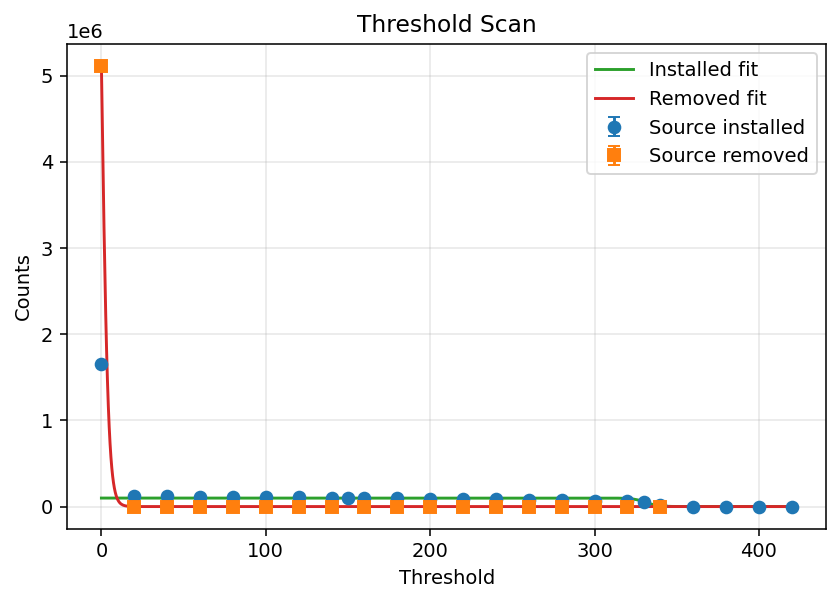

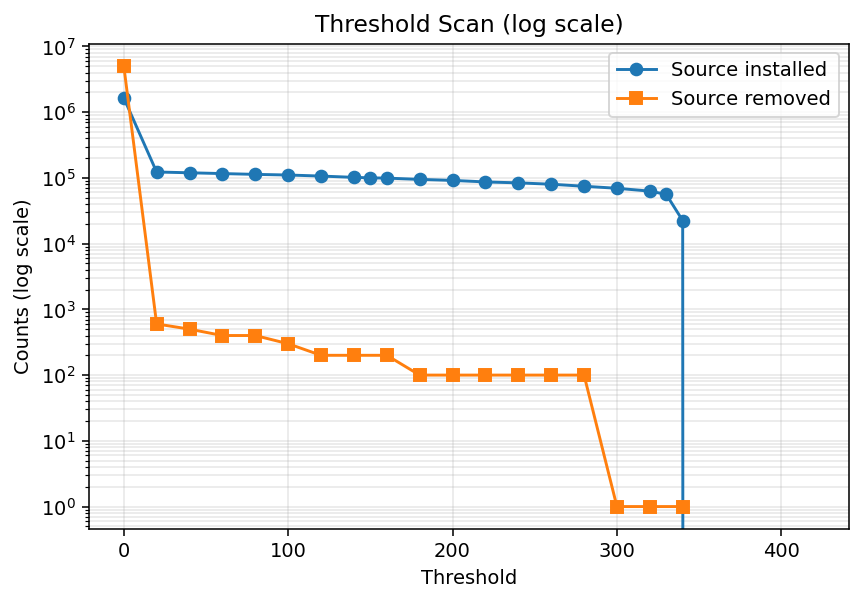

Quick interpretation for preparation
------------------------------------------------------------------------
Prompt curve: optimal delay t0 = 46.080 ± 0.112
Prompt curve: plateau width w = 31.839 ± 0.247
Prompt curve: slope width sigma = 5.158 ± 0.225

Angular correlation: A = 10003.64790 ± 46.9
Angular correlation: B = 0.09272 ± 0.0267
Angular correlation: C = 0.07908 ± 0.0262
Angular correlation: alpha = 0.17180 ± 0.0374
Angular correlation: beta  = 0.01364 ± 0.0374

For the lab-report part:
- Use the prompt-curve fit parameters to discuss resolving time and slope width.
- Use A, B, C and especially alpha, beta for the preparation-angle discussion.


In [1]:
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

# Make plots appear inline in Jupyter
%matplotlib inline

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"

# ============================================================
# CONFIG
# ============================================================
ODS_PATH = Path(r"C:\Users\syedm\Code\K223 Pseudo Data.ods")

# ============================================================
# HELPERS
# ============================================================
def poisson_sigma(y):
    """Poisson uncertainty, with floor to avoid zero division."""
    y = np.asarray(y, dtype=float)
    return np.sqrt(np.clip(y, 1.0, None))

def chi2_ndf(y, yfit, sigma, npar):
    chi2 = np.sum(((y - yfit) / sigma) ** 2)
    ndf = max(len(y) - npar, 1)
    return chi2, ndf, chi2 / ndf

def print_fit_result(title, names, popt, perr, chi2=None, ndf=None, chi2ndf=None, extra_lines=None):
    print("=" * 72)
    print(title)
    print("-" * 72)
    for name, val, err in zip(names, popt, perr):
        print(f"{name:>12s} = {val:12.6g} ± {err:.3g}")
    if extra_lines:
        for line in extra_lines:
            print(line)
    if chi2 is not None:
        print(f"{'chi2':>12s} = {chi2:.6g}")
    if ndf is not None:
        print(f"{'ndf':>12s} = {ndf}")
    if chi2ndf is not None:
        print(f"{'chi2/ndf':>12s} = {chi2ndf:.6g}")
    print()

def safe_curve_fit(model, x, y, sigma, p0, bounds, maxfev=50000):
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=p0,
        sigma=sigma,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=maxfev,
    )
    perr = np.sqrt(np.diag(pcov))
    yfit = model(x, *popt)
    chi2, ndf, chi2ndf = chi2_ndf(y, yfit, sigma, len(popt))
    return popt, perr, yfit, chi2, ndf, chi2ndf

# ============================================================
# MODELS
# ============================================================
def prompt_curve_model(t, A, t0, w, sigma, A0):
    """
    f(t) = A/2 * [1 + erf((t-(t0-w/2))/sigma) * erf(((t0+w/2)-t)/sigma)] + A0
    """
    return 0.5 * A * (
        1.0
        + erf((t - (t0 - w / 2.0)) / sigma)
        * erf(((t0 + w / 2.0) - t) / sigma)
    ) + A0

def angular_corr_cos_model(theta_deg, A, B, C):
    """
    Preparation-task angular correlation form:
    f(theta) = A * (1 + B cos^2(theta) + C cos^4(theta))
    """
    th = np.deg2rad(theta_deg)
    c2 = np.cos(th) ** 2
    c4 = np.cos(th) ** 4
    return A * (1.0 + B * c2 + C * c4)

def gaussian(x, amp, mu, sigma, bg):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + bg

def two_gaussians_shared_bg(x, amp1, mu1, sigma1, amp2, mu2, sigma2, bg):
    return (
        amp1 * np.exp(-0.5 * ((x - mu1) / sigma1) ** 2)
        + amp2 * np.exp(-0.5 * ((x - mu2) / sigma2) ** 2)
        + bg
    )

def logistic_drop(x, high, x0, k, low):
    """
    Practical helper fit for threshold scans.
    This is not a fundamental physics model; it is just useful for locating
    the turnoff region cleanly in the pseudo-data.
    """
    return low + (high - low) / (1.0 + np.exp((x - x0) / k))

# ============================================================
# LOAD FILE
# ============================================================
if not ODS_PATH.exists():
    raise FileNotFoundError(f"Could not find file:\n{ODS_PATH}")

print(f"Reading file: {ODS_PATH}")
xls = pd.ExcelFile(ODS_PATH, engine="odf")
print("Sheets found:", xls.sheet_names)
print()

# ============================================================
# 1) PROMPT CURVE
# ============================================================
df_prompt = pd.read_excel(ODS_PATH, sheet_name="Prompt Curve", engine="odf")
df_prompt = df_prompt.dropna().reset_index(drop=True)

t_prompt = df_prompt.iloc[:, 0].to_numpy(dtype=float)
y_prompt = df_prompt.iloc[:, 1].to_numpy(dtype=float)
s_prompt = poisson_sigma(y_prompt)

A_guess = max(y_prompt) - min(y_prompt)
A0_guess = np.percentile(y_prompt, 10)

mask_top = y_prompt > (A0_guess + 0.7 * A_guess)
if np.any(mask_top):
    t0_guess = np.mean(t_prompt[mask_top])
    w_guess = max(np.max(t_prompt[mask_top]) - np.min(t_prompt[mask_top]), 5.0)
else:
    t0_guess = t_prompt[np.argmax(y_prompt)]
    w_guess = 10.0

sigma_guess = 2.0
p0_prompt = [A_guess, t0_guess, w_guess, sigma_guess, A0_guess]
bounds_prompt = (
    [0.0, np.min(t_prompt) - 20, 0.1, 0.1, 0.0],
    [10 * np.max(y_prompt), np.max(t_prompt) + 20, 200.0, 50.0, np.max(y_prompt)],
)

popt_prompt, perr_prompt, yfit_prompt, chi2_prompt, ndf_prompt, chi2ndf_prompt = safe_curve_fit(
    prompt_curve_model, t_prompt, y_prompt, s_prompt, p0_prompt, bounds_prompt
)

A_p, t0_p, w_p, sigma_p, A0_p = popt_prompt
dA_p, dt0_p, dw_p, dsigma_p, dA0_p = perr_prompt

print_fit_result(
    "Prompt Curve Fit (manual Eq. 4 style)",
    ["A", "t0", "w", "sigma", "A0"],
    popt_prompt,
    perr_prompt,
    chi2_prompt,
    ndf_prompt,
    chi2ndf_prompt,
    extra_lines=[
        f"{'meaning':>12s} = w is plateau width / resolving-time proxy",
        f"{'':>12s}   sigma is slope width"
    ]
)

tt = np.linspace(np.min(t_prompt), np.max(t_prompt), 800)
plt.figure(figsize=(7, 4.5))
plt.errorbar(t_prompt, y_prompt, yerr=s_prompt, fmt="o", capsize=3, label="Data")
plt.plot(tt, prompt_curve_model(tt, *popt_prompt), label="Fit")
plt.axvline(t0_p, linestyle="--", label=f"t0 = {t0_p:.2f}")
plt.axvspan(t0_p - w_p/2, t0_p + w_p/2, alpha=0.15, label=f"w = {w_p:.2f}")
plt.xlabel("Delay")
plt.ylabel("Coincidence count rate")
plt.title("Prompt Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 2) SPECTRUM
# ============================================================
df_spectrum = pd.read_excel(ODS_PATH, sheet_name="Spectrum", engine="odf")
df_spectrum = df_spectrum.dropna().reset_index(drop=True)

x_spec = df_spectrum.iloc[:, 0].to_numpy(dtype=float)
y_spec = df_spectrum.iloc[:, 1].to_numpy(dtype=float)
s_spec = poisson_sigma(y_spec)

# Heuristic fit window for the visible double structure in the pseudo-data
spec_mask = (x_spec >= 70) & (x_spec <= 155)
x_spec_fit = x_spec[spec_mask]
y_spec_fit = y_spec[spec_mask]
s_spec_fit = poisson_sigma(y_spec_fit)

popt_spec = perr_spec = yfit_spec = None
chi2_spec = ndf_spec = chi2ndf_spec = None

try:
    p0_spec = [900.0, 95.0, 8.0, 1800.0, 129.0, 6.0, 3000.0]
    bounds_spec = (
        [0.0, 70.0, 0.5, 0.0, 110.0, 0.5, 0.0],
        [1e6, 110.0, 30.0, 1e6, 150.0, 30.0, 1e6],
    )

    popt_spec, perr_spec, yfit_spec, chi2_spec, ndf_spec, chi2ndf_spec = safe_curve_fit(
        two_gaussians_shared_bg,
        x_spec_fit,
        y_spec_fit,
        s_spec_fit,
        p0_spec,
        bounds_spec
    )

    print_fit_result(
        "Spectrum Fit (practical helper fit: 2 Gaussians + constant background)",
        ["amp1", "mu1", "sigma1", "amp2", "mu2", "sigma2", "bg"],
        popt_spec,
        perr_spec,
        chi2_spec,
        ndf_spec,
        chi2ndf_spec
    )
except Exception as exc:
    print("=" * 72)
    print("Spectrum Fit")
    print("-" * 72)
    print("Spectrum fit failed:", exc)
    print()

plt.figure(figsize=(7, 4.5))
plt.errorbar(x_spec, y_spec, yerr=s_spec, fmt="o", capsize=2, label="Data")

if popt_spec is not None:
    xx = np.linspace(np.min(x_spec_fit), np.max(x_spec_fit), 800)
    plt.plot(xx, two_gaussians_shared_bg(xx, *popt_spec), label="Double-Gaussian fit")

    amp1, mu1, sig1, amp2, mu2, sig2, bg = popt_spec
    plt.plot(xx, gaussian(xx, amp1, mu1, sig1, 0), "--", label=f"Peak 1 @ {mu1:.2f}")
    plt.plot(xx, gaussian(xx, amp2, mu2, sig2, 0), "--", label=f"Peak 2 @ {mu2:.2f}")

plt.xlabel("Channel (or energy )")
plt.ylabel("Counts")
plt.title("Spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ============================================================
# 3) ANGULAR CORRELATION
# ============================================================
df_ang = pd.read_excel(ODS_PATH, sheet_name="Angular Correlation", engine="odf")
df_ang = df_ang.dropna().reset_index(drop=True)

theta = df_ang.iloc[:, 0].to_numpy(dtype=float)
y_ang = df_ang.iloc[:, 1].to_numpy(dtype=float)
s_ang = poisson_sigma(y_ang)

p0_ang = [np.mean(y_ang), 0.1, 0.02]
bounds_ang = ([0.0, -5.0, -5.0], [10 * np.max(y_ang), 5.0, 5.0])

popt_ang, perr_ang, yfit_ang, chi2_ang, ndf_ang, chi2ndf_ang = safe_curve_fit(
    angular_corr_cos_model, theta, y_ang, s_ang, p0_ang, bounds_ang
)

A_fit, B_fit, C_fit = popt_ang
dA_fit, dB_fit, dC_fit = perr_ang

alpha_fit = B_fit + C_fit
beta_fit = B_fit - C_fit
dalpha_fit = np.sqrt(dB_fit**2 + dC_fit**2)
dbeta_fit = np.sqrt(dB_fit**2 + dC_fit**2)

print_fit_result(
    "Angular Correlation Fit",
    ["A", "B", "C"],
    popt_ang,
    perr_ang,
    chi2_ang,
    ndf_ang,
    chi2ndf_ang,
    extra_lines=[
        f"{'alpha':>12s} = {alpha_fit:12.6g} ± {dalpha_fit:.3g}",
        f"{'beta':>12s} = {beta_fit:12.6g} ± {dbeta_fit:.3g}",
        f"{'meaning':>12s} = alpha = B + C, beta = B - C"
    ]
)

th_dense = np.linspace(np.min(theta), np.max(theta), 800)
plt.figure(figsize=(7, 4.5))
plt.errorbar(theta, y_ang, yerr=s_ang, fmt="o", capsize=3, label="Data")
plt.plot(th_dense, angular_corr_cos_model(th_dense, *popt_ang), label="Fit")
plt.xlabel("Angle [deg]")
plt.ylabel("Coincidences")
plt.title("Angular Correlation")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# 4) THRESHOLD SCAN
# ============================================================
df_thr_raw = pd.read_excel(ODS_PATH, sheet_name="Threshold Scan", engine="odf", header=None)

# left block = source installed
left = df_thr_raw.iloc[2:, [0, 1]].copy()
left.columns = ["Threshold", "Counts"]
left = left.dropna().reset_index(drop=True)
left["Threshold"] = pd.to_numeric(left["Threshold"], errors="coerce")
left["Counts"] = pd.to_numeric(left["Counts"], errors="coerce")
left = left.dropna().reset_index(drop=True)

# right block = source removed
right = df_thr_raw.iloc[2:, [3, 4]].copy()
right.columns = ["Threshold", "Counts"]
right = right.dropna().reset_index(drop=True)
right["Threshold"] = pd.to_numeric(right["Threshold"], errors="coerce")
right["Counts"] = pd.to_numeric(right["Counts"], errors="coerce")
right = right.dropna().reset_index(drop=True)

x_thr_in = left["Threshold"].to_numpy(dtype=float)
y_thr_in = left["Counts"].to_numpy(dtype=float)
s_thr_in = poisson_sigma(y_thr_in)

x_thr_out = right["Threshold"].to_numpy(dtype=float)
y_thr_out = right["Counts"].to_numpy(dtype=float)
s_thr_out = poisson_sigma(y_thr_out)

# helper fits
p0_thr_in = [np.max(y_thr_in), 335.0, 10.0, 0.0]
bounds_thr_in = ([0.0, 0.0, 0.1, 0.0], [1e8, 1000.0, 200.0, 1e8])

popt_thr_in, perr_thr_in, yfit_thr_in, chi2_thr_in, ndf_thr_in, chi2ndf_thr_in = safe_curve_fit(
    logistic_drop, x_thr_in, y_thr_in, s_thr_in, p0_thr_in, bounds_thr_in
)

p0_thr_out = [np.max(y_thr_out), 40.0, 8.0, 0.0]
bounds_thr_out = ([0.0, 0.0, 0.1, 0.0], [1e8, 1000.0, 200.0, 1e8])

popt_thr_out, perr_thr_out, yfit_thr_out, chi2_thr_out, ndf_thr_out, chi2ndf_thr_out = safe_curve_fit(
    logistic_drop, x_thr_out, y_thr_out, s_thr_out, p0_thr_out, bounds_thr_out
)

print_fit_result(
    "Threshold Scan Fit — Source Installed (helper fit)",
    ["high", "x0", "k", "low"],
    popt_thr_in,
    perr_thr_in,
    chi2_thr_in,
    ndf_thr_in,
    chi2ndf_thr_in,
    extra_lines=[
        f"{'meaning':>12s} = x0 is the approximate threshold turnoff point"
    ]
)

print_fit_result(
    "Threshold Scan Fit — Source Removed (helper fit)",
    ["high", "x0", "k", "low"],
    popt_thr_out,
    perr_thr_out,
    chi2_thr_out,
    ndf_thr_out,
    chi2ndf_thr_out,
    extra_lines=[
        f"{'meaning':>12s} = useful for comparing noise/background behavior"
    ]
)

plt.figure(figsize=(7, 4.5))
plt.errorbar(x_thr_in, y_thr_in, yerr=s_thr_in, fmt="o", capsize=3, label="Source installed")
plt.errorbar(x_thr_out, y_thr_out, yerr=s_thr_out, fmt="s", capsize=3, label="Source removed")

xx = np.linspace(
    min(np.min(x_thr_in), np.min(x_thr_out)),
    max(np.max(x_thr_in), np.max(x_thr_out)),
    800,
)
plt.plot(xx, logistic_drop(xx, *popt_thr_in), label="Installed fit")
plt.plot(xx, logistic_drop(xx, *popt_thr_out), label="Removed fit")
plt.xlabel("Threshold")
plt.ylabel("Counts")
plt.title("Threshold Scan")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.semilogy(x_thr_in, y_thr_in, "o-", label="Source installed")
plt.semilogy(x_thr_out, np.clip(y_thr_out, 1, None), "s-", label="Source removed")
plt.xlabel("Threshold")
plt.ylabel("Counts (log scale)")
plt.title("Threshold Scan (log scale)")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.show()

# ============================================================
# SHORT PHYSICS SUMMARY PRINTED AT END
# ============================================================
print("=" * 72)
print("Quick interpretation for preparation")
print("-" * 72)
print(f"Prompt curve: optimal delay t0 = {t0_p:.3f} ± {dt0_p:.3f}")
print(f"Prompt curve: plateau width w = {w_p:.3f} ± {dw_p:.3f}")
print(f"Prompt curve: slope width sigma = {sigma_p:.3f} ± {dsigma_p:.3f}")
print()
print(f"Angular correlation: A = {A_fit:.5f} ± {dA_fit:.3g}")
print(f"Angular correlation: B = {B_fit:.5f} ± {dB_fit:.3g}")
print(f"Angular correlation: C = {C_fit:.5f} ± {dC_fit:.3g}")
print(f"Angular correlation: alpha = {alpha_fit:.5f} ± {dalpha_fit:.3g}")
print(f"Angular correlation: beta  = {beta_fit:.5f} ± {dbeta_fit:.3g}")
print()
print("For the lab-report part:")
print("- Use the prompt-curve fit parameters to discuss resolving time and slope width.")
print("- Use A, B, C and especially alpha, beta for the preparation-angle discussion.")
print("=" * 72)

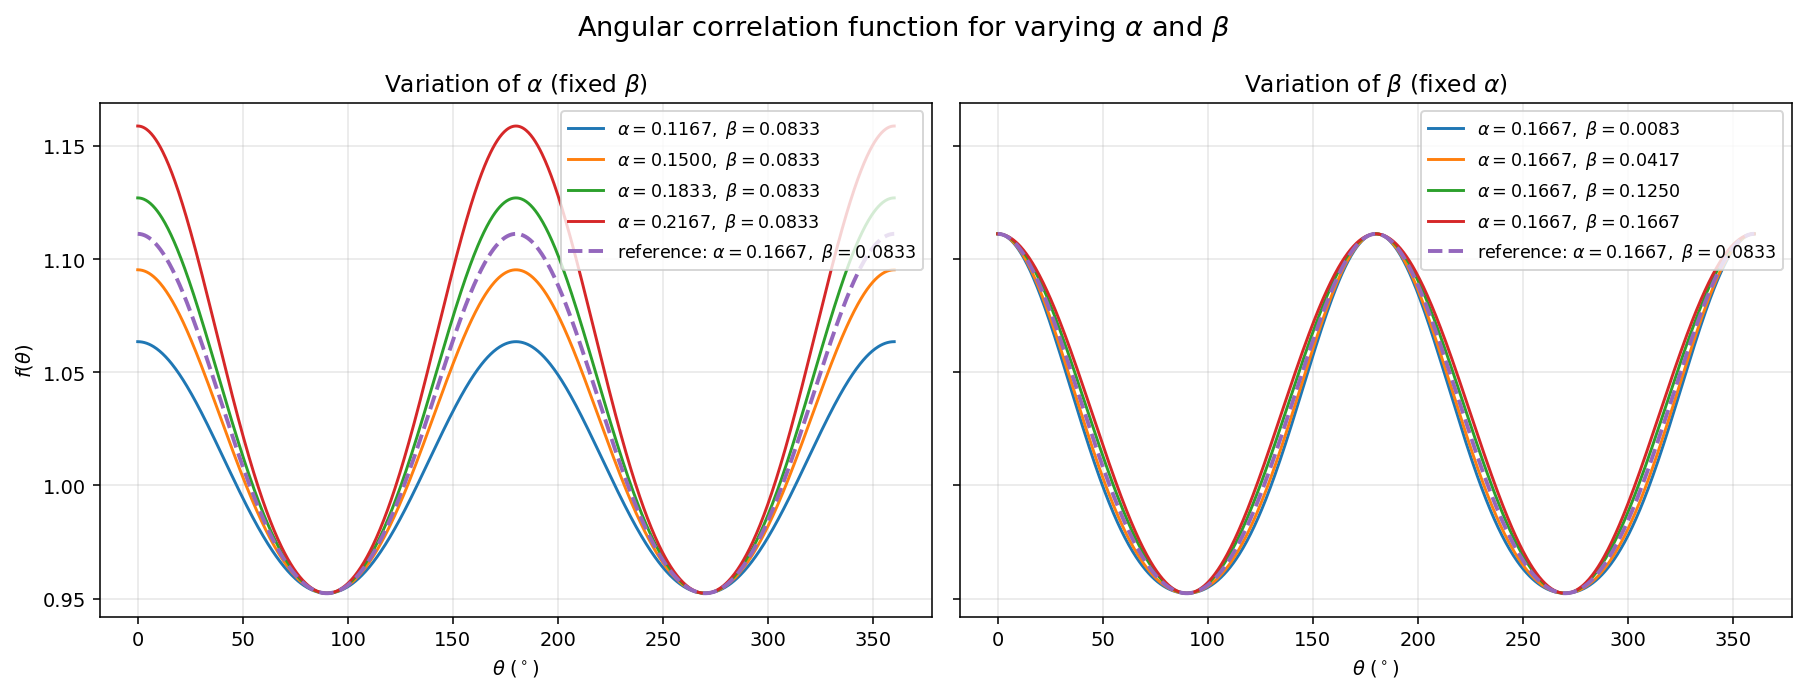

In [2]:

A = 0.9524
alpha0 = 1/6
beta0 = 1/12

# Angular correlation function written in terms of alpha and beta
def f_theta(theta_deg, A, alpha, beta):
    theta = np.deg2rad(theta_deg)
    return A * (
        1
        + 0.5 * (alpha + beta) * np.cos(theta)**2
        + 0.5 * (alpha - beta) * np.cos(theta)**4
    )

# Angle grid
theta_deg = np.linspace(0, 360, 1000)

# Choose 4 varying alpha values around the report value, beta fixed
alpha_values = [0.7 * alpha0, 0.9 * alpha0, 1.1 * alpha0, 1.3 * alpha0]

# Choose 4 varying beta values around the report value, alpha fixed
beta_values = [0.1 * beta0, 0.5 * beta0, 1.5 * beta0, 2.0 * beta0]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Left subplot: varying alpha
for alpha in alpha_values:
    axes[0].plot(
        theta_deg,
        f_theta(theta_deg, A, alpha, beta0),
        label=fr"$\alpha={alpha:.4f},\ \beta={beta0:.4f}$"
    )

axes[0].plot(
    theta_deg,
    f_theta(theta_deg, A, alpha0, beta0),
    linestyle="--",
    linewidth=2,
    label=fr"reference: $\alpha={alpha0:.4f},\ \beta={beta0:.4f}$"
)
axes[0].set_title(r"Variation of $\alpha$ (fixed $\beta$)")
axes[0].set_xlabel(r"$\theta\;(^\circ)$")
axes[0].set_ylabel(r"$f(\theta)$")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Right subplot: varying beta
for beta in beta_values:
    axes[1].plot(
        theta_deg,
        f_theta(theta_deg, A, alpha0, beta),
        label=fr"$\alpha={alpha0:.4f},\ \beta={beta:.4f}$"
    )

axes[1].plot(
    theta_deg,
    f_theta(theta_deg, A, alpha0, beta0),
    linestyle="--",
    linewidth=2,
    label=fr"reference: $\alpha={alpha0:.4f},\ \beta={beta0:.4f}$"
)
axes[1].set_title(r"Variation of $\beta$ (fixed $\alpha$)")
axes[1].set_xlabel(r"$\theta\;(^\circ)$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle(r"Angular correlation function for varying $\alpha$ and $\beta$", fontsize=14)
plt.tight_layout()
plt.savefig("voraufgabe_angular_correlation_variation.png")
plt.show()

Prompt Curve Fit (manual Eq. 4 style)
------------------------------------------------------------------------
           A =      79.8642 ± 2.55
          t0 =     -13.4016 ± 0.16
           w =      44.6952 ± 0.406
       sigma =      2.17088 ± 0.298
          A0 =      1.57019 ± 0.659
     meaning = w is plateau width / resolving-time proxy
               sigma is slope width
        chi2 = 10.7601
         ndf = 19
    chi2/ndf = 0.566324



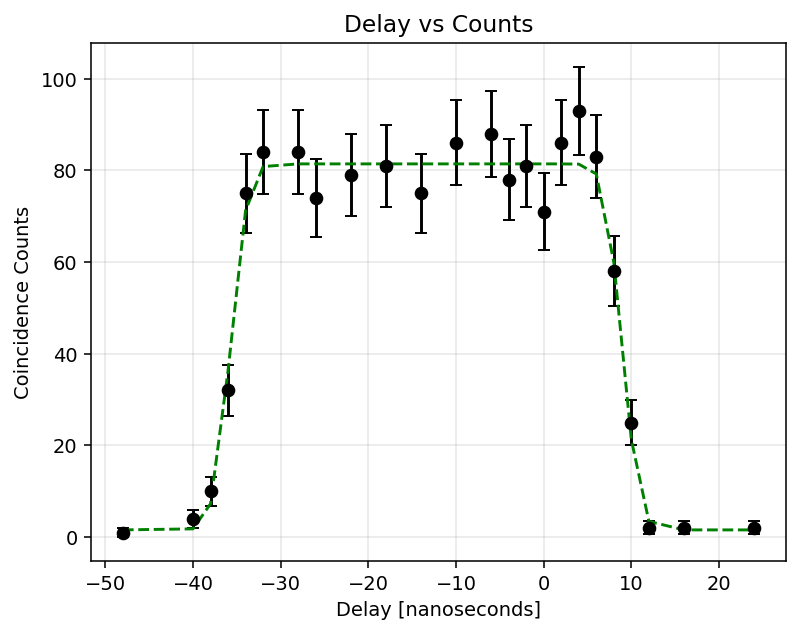

In [6]:
#measurement time of 20 seconds
import numpy as np
import matplotlib.pyplot as plt
delay = np.array([-48,-40,-38, -36,-34,  -32, -28, -26, -22,-18,-14, -10, -6, -4, -2, 0, 2, 4, 6, 8, 10,12, 16, 24])
counts = np.array([1,4, 10, 32, 75,  84 , 84,74, 79, 81, 75, 86 ,88 ,78, 81, 71, 86, 93, 83, 58, 25 ,2 , 2, 2])
p0_prompt = [80, 0, 10, 2, 20]
bounds_prompt = (
    [0.0, -50.0, 0.1, 0.1, 0.0],
    [200.0, 50.0, 100.0, 20.0, 200.0],
)

#fit the prompt curve as above to this data
popt, perr, yfit, chi2, ndf, chi2ndf = safe_curve_fit(
    prompt_curve_model, delay, counts, poisson_sigma(counts), p0_prompt, bounds_prompt
)
#reduced chi2 should be around 1 for a good fit
print_fit_result(
    "Prompt Curve Fit (manual Eq. 4 style)",
    ["A", "t0", "w", "sigma", "A0"],
    popt,
    perr,
    chi2,
    ndf,
    chi2ndf,
    extra_lines=[
        f"{'meaning':>12s} = w is plateau width / resolving-time proxy",
        f"{'':>12s}   sigma is slope width"
    ]
)

plt.errorbar(delay, counts, yerr=poisson_sigma(counts), fmt="o", capsize=3, label="Data", color = "black")
plt.plot(delay, prompt_curve_model(delay, *popt), label="Fit", color = "green", linestyle="--")
plt.xlabel("Delay [nanoseconds]")
plt.ylabel("Coincidence Counts")
plt.title("Delay vs Counts")
plt.grid(alpha=0.3)
plt.savefig("prompt_curve_fit.png")
plt.show()